# Supplementary — Loss Taxonomy

Explain where agreements drop between successive rungs (2→3, 3→4, 4→5), partitioning losses into interpretable categories.

In [3]:
import os, shutil
from pathlib import Path
import matplotlib as mpl
from matplotlib import font_manager as fm
# Use local scratch for Matplotlib cache to avoid stale NFS handles
try:
    MPLDIR = Path('/tmp') / f"{os.environ.get('USER','user')}-mplconfig"
    MPLDIR.mkdir(parents=True, exist_ok=True)
    os.environ['MPLCONFIGDIR'] = str(MPLDIR)
    # Copy bundled DejaVu fonts to local scratch and register
    import matplotlib
    ttf_src = Path(matplotlib.get_data_path())/'fonts'/'ttf'
    ttf_dst = MPLDIR/'ttf'
    shutil.copytree(ttf_src, ttf_dst, dirs_exist_ok=True)
    for f in ttf_dst.glob('*.ttf'):
        fm.fontManager.addfont(str(f))
    fm._load_fontmanager(try_read_cache=False)
    mpl.rcParams.update({'svg.fonttype':'none', 'pdf.fonttype':42, 'ps.fonttype':42,
                         'font.family':'DejaVu Sans'})
except Exception as e:
    print('Font init warning:', e)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings

OUTPUT_DIR  = Path('/hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results')
QC_DIR      = OUTPUT_DIR / 'qc_metrics'
RESULTS_DIR = OUTPUT_DIR / 'results'
SUMMARY_DIR = OUTPUT_DIR / 'summary_stats'
FIGURE_DIR  = OUTPUT_DIR / 'figures'
FIGURE_DIR.mkdir(exist_ok=True, parents=True)

# Parameters
RBH_COVERAGE_THRESHOLD = float(globals().get('RBH_COVERAGE_THRESHOLD', 0.95))
RUNG4_DENOM = globals().get('RUNG4_DENOM', 'monotonic')
SAMPLE_RBH = int(globals().get('SAMPLE_RBH', 0))  # 0 = no sampling


In [10]:
from collections import defaultdict, Counter
import pandas as pd
import numpy as np
import warnings
import re

def get_acc_from_name(filename: str) -> str | None:
    m = re.search(r"(GC[AF]_\d+\.\d+)", filename)
    return m.group(1) if m else None

def norm_id(s: pd.Series) -> pd.Series:
    return s.astype("string").str.strip().str.replace(r"\.\d+$", "", regex=True)

def pick_gene_col(df: pd.DataFrame) -> str | None:
    for c in ["ensembl_gene_id", "ens_gene_id", "gene_id"]:
        if c in df.columns: return c
    for c in ["ensembl_id", "ensembl", "ens_id"]:
        if c in df.columns: return c
    return None

skip = Counter()
examples = defaultdict(list)

counts = defaultdict(int)
assemblies = set()

rbh_files = sorted(RESULTS_DIR.rglob("*.gene_pairs_rbh.tsv"))

for rbh_path in rbh_files:
    acc = get_acc_from_name(rbh_path.name)
    if acc is None:
        skip["acc_parse_fail"] += 1
        continue
    assemblies.add(acc)

    try:
        rbh = pd.read_csv(rbh_path, sep="\t")
    except Exception:
        skip["rbh_read_fail"] += 1
        continue

    if not {"frac_ensembl_covered","frac_cat_covered"}.issubset(rbh.columns):
        skip["rbh_missing_cov_cols"] += 1
        continue

    r2 = rbh[
        (rbh["frac_ensembl_covered"] >= RBH_COVERAGE_THRESHOLD) &
        (rbh["frac_cat_covered"]    >= RBH_COVERAGE_THRESHOLD)
    ].copy()

    gene_col = pick_gene_col(r2)
    if gene_col is None:
        skip["rbh_no_gene_col"] += 1
        continue

    r2[gene_col] = norm_id(r2[gene_col])
    r2_genes = set(r2[gene_col].dropna().unique())
    if not r2_genes:
        skip["r2_empty_gene_set"] += 1
        continue

    counts["r2_denom"] += len(r2_genes)

    # ---- TC ----
    tc_path = next(QC_DIR.rglob(f"{acc}_transcript_concordance.tsv"), None)
    if tc_path is None:
        skip["tc_missing"] += 1
        continue

    try:
        tc = pd.read_csv(tc_path, sep="\t")
    except Exception:
        skip["tc_read_fail"] += 1
        continue

    tc_gene_col = "ensembl_gene_id" if "ensembl_gene_id" in tc.columns else ("ensembl_id" if "ensembl_id" in tc.columns else None)
    if tc_gene_col is None:
        skip["tc_no_gene_col"] += 1
        continue

    if "n_ens_exact" not in tc.columns and "n_cat_exact" not in tc.columns:
        skip["tc_no_exact_cols"] += 1
        if len(examples["tc_no_exact_cols"]) < 3:
            examples["tc_no_exact_cols"].append((acc, tc_path.name, list(tc.columns)[:25]))
        continue

    tc[tc_gene_col] = norm_id(tc[tc_gene_col])
    tc = tc[tc[tc_gene_col].isin(r2_genes)].copy()

    if tc.empty:
        skip["tc_join_empty"] += 1
        if len(examples["tc_join_empty"]) < 5:
            examples["tc_join_empty"].append((acc, gene_col, tc_gene_col, list(sorted(list(r2_genes)))[:3]))
        continue

    # exact
    n_ens_exact = tc["n_ens_exact"].fillna(0) if "n_ens_exact" in tc.columns else 0
    n_cat_exact = tc["n_cat_exact"].fillna(0) if "n_cat_exact" in tc.columns else 0
    exact = (n_ens_exact >= 1) | (n_cat_exact >= 1)

    r3_genes = set(tc.loc[exact, tc_gene_col].dropna().unique())
    counts["r3_pass"] += int(exact.sum())
    counts["r3_denom"] += len(r3_genes)

    if not r3_genes:
        skip["r3_empty_after_exact"] += 1
        continue

    # ---- CI ----
    ci_path = next(QC_DIR.rglob(f"{acc}_coding_integrity.tsv"), None)
    if ci_path is None:
        skip["ci_missing"] += 1
        continue

    try:
        ci = pd.read_csv(ci_path, sep="\t")
    except Exception:
        skip["ci_read_fail"] += 1
        continue

    ci_gene_col = "ensembl_gene_id" if "ensembl_gene_id" in ci.columns else ("ensembl_id" if "ensembl_id" in ci.columns else None)
    if ci_gene_col is None:
        skip["ci_no_gene_col"] += 1
        continue

    ci[ci_gene_col] = norm_id(ci[ci_gene_col])
    ci = ci[ci[ci_gene_col].isin(r3_genes)].copy()
    if ci.empty:
        skip["ci_join_empty"] += 1
        continue

    # at least prove we got here
    counts["ci_rows_seen"] += len(ci)

print("Assemblies:", len(assemblies))
print("Counts:", dict(counts))
print("\nTop skip reasons:")
for k,v in skip.most_common(20):
    print(f"  {k:20s} {v}")

print("\nExamples:")
for k, vals in examples.items():
    print(f"\n{k}:")
    for v in vals:
        print(" ", v)

Assemblies: 462
Counts: {'r2_denom': 33671190, 'r3_pass': 32699506, 'r3_denom': 32699506, 'ci_rows_seen': 8061826}

Top skip reasons:
  r2_empty_gene_set    6

Examples:


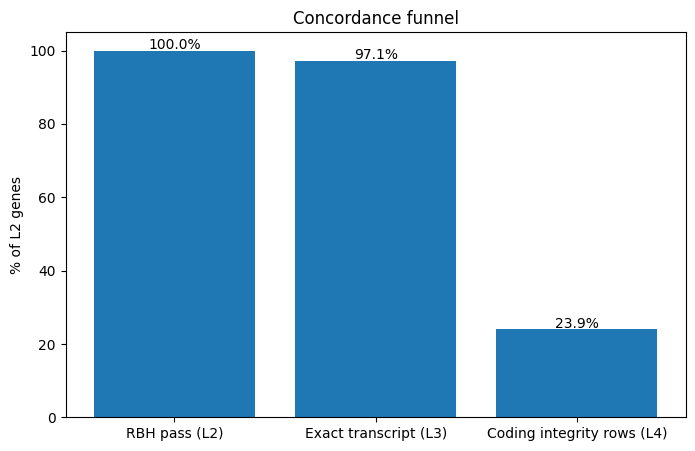

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# --- counts ---
r2 = counts["r2_denom"]
r3 = counts["r3_denom"]
ci = counts["ci_rows_seen"]   # NOTE: different unit — see warning below

labels = ["RBH pass (L2)", "Exact transcript (L3)", "Coding integrity rows (L4)"]
vals   = [r2, r3, ci]

# convert to percentages relative to L2
pct = [v / r2 * 100 for v in vals]

fig, ax = plt.subplots(figsize=(8,5))

ax.bar(labels, pct)

ax.set_ylabel("% of L2 genes")
ax.set_title("Concordance funnel")

for i, p in enumerate(pct):
    ax.text(i, p + 0.5, f"{p:.1f}%", ha="center")

plt.show()

In [8]:
import re
from collections import Counter

def get_acc_from_name(filename: str) -> str | None:
    m = re.search(r"(GC[AF]_\d+\.\d+)", filename)
    return m.group(1) if m else None

rbh_files = sorted(RESULTS_DIR.rglob("*.gene_pairs_rbh.tsv"))

acc_bad = 0
tc_missing = 0
examples = []

for rbh_path in rbh_files[:50]:  # sample first 50
    acc_old = rbh_path.name.split(".")[0]
    acc_new = get_acc_from_name(rbh_path.name)

    if acc_new is None:
        acc_bad += 1
        continue

    tc_path = next(QC_DIR.rglob(f"{acc_new}_transcript_concordance.tsv"), None)
    if tc_path is None:
        tc_missing += 1
        if len(examples) < 5:
            examples.append((rbh_path.name, acc_old, acc_new))

print("Sampled RBH files:", len(rbh_files[:50]))
print("No regex accession found:", acc_bad)
print("TC missing (using regex acc):", tc_missing)
print("\nExamples (rbh_filename, acc_old, acc_new):")
for ex in examples:
    print("  ", ex)

Sampled RBH files: 50
No regex accession found: 0
TC missing (using regex acc): 0

Examples (rbh_filename, acc_old, acc_new):


In [9]:
# pick ONE assembly that you know exists
rbh_path = rbh_files[0]
rbh = pd.read_csv(rbh_path, sep="\t")

print("RBH columns:", list(rbh.columns)[:30])

# after your r2 filter:
r2 = rbh[(rbh['frac_ensembl_covered'] >= RBH_COVERAGE_THRESHOLD) & (rbh['frac_cat_covered'] >= RBH_COVERAGE_THRESHOLD)]
gene_col = 'ensembl_gene_id' if 'ensembl_gene_id' in r2.columns else ('ensembl_id' if 'ensembl_id' in r2.columns else None)
print("gene_col chosen:", gene_col)
print("rows in r2:", len(r2))
print("unique IDs in gene_col:", r2[gene_col].nunique(dropna=True))
print("first 10 IDs:", r2[gene_col].dropna().astype(str).head(10).tolist())

RBH columns: ['ensembl_id', 'cat_id', 'ensembl_length', 'cat_length', 'ensembl_biotype', 'cat_biotype', 'ensembl_name', 'cat_name', 'is_name_match', 'overlap_bp', 'frac_ensembl_covered', 'frac_cat_covered', 'is_spatial', 'ensembl_start', 'ensembl_end', 'cat_start', 'cat_end', 'strand', 'classification_detailed', 'diff_5prime', 'diff_3prime', 'classification', 'is_rbh']
gene_col chosen: ensembl_id
rows in r2: 0
unique IDs in gene_col: 0
first 10 IDs: []


NameError: name 'per_asm' is not defined